# 04 — Intent-tree comparison: real conversations vs. artifacts

**The thesis comparison.** DiscoverLLM builds intent trees from *synthetic artifacts*. This project
builds DiscoverLLM-style trees from *real conversations* (ThoughtTrace). This notebook compares the two
on shared structural metrics — **nodes per tree, depth, branching**.

Both sides are scoped to what a conversation actually surfaces: the DiscoverLLM artifact trees are
restricted to **green + yellow** (`aware`/`satisfied`) nodes (re-parented to nearest kept ancestor), and
the ThoughtTrace side is the extracted trees (which are surfaced by construction).

## Sources

- **Artifact-derived** (DiscoverLLM): official `kixlab/DiscoverLLM-multiturn-preferences`,
  `criteria_history → hierarchy` (nested `{id, text, children, aware, satisfied}`), scoped to
  **green+yellow** surfaced nodes.
- **Real-conversation-derived** (ThoughtTrace): `gpt-5.4-mini` extractions under
  `data/extractions_gpt54mini/*.json` (schema `trees[].nodes[]`, flat parent-pointer).

In [1]:
import os
import json
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

def _repo_root():
    for cand in [Path.cwd(), *Path.cwd().parents]:
        if (cand / "requirements.txt").exists() and (cand / "notebooks").is_dir():
            return cand
    return Path.cwd()

ROOT = _repo_root()
pd.set_option("display.width", 120)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- Shared structural helpers (flat node lists with id + parent_id) ---
def extract_hierarchies(s):
    roots = []
    try:
        parsed = json.loads(s) if isinstance(s, str) else s
    except Exception:
        return roots
    stack, seen = [parsed], set()
    while stack:
        x = stack.pop()
        if isinstance(x, list):
            stack.extend(x)
        elif isinstance(x, dict):
            if isinstance(x.get("hierarchy"), list):
                k = str(x.get("criterion", ""))[:80]
                if k not in seen:
                    seen.add(k); roots.extend(x["hierarchy"])
            for v in x.values():
                if isinstance(v, (list, dict)):
                    stack.append(v)
    return roots

def _keep(n, scope):
    if scope == "green":
        return n.get("satisfied", 0) > 0
    return n.get("aware", 0) > 0 or n.get("satisfied", 0) > 0   # surfaced = green + yellow

def scoped_flatten(roots, scope="surfaced"):
    """Nested GT roots -> per-tree flat node lists, keeping `scope` nodes, re-parented to nearest kept ancestor."""
    out = []
    def walk(n, kept_parent, acc):
        nid = str(n["id"])
        if _keep(n, scope):
            acc.append({"id": nid, "parent_id": kept_parent}); nxt = nid
        else:
            nxt = kept_parent
        for c in n.get("children", []):
            walk(c, nxt, acc)
    for r in roots:
        acc = []; walk(r, None, acc)
        if acc:
            out.append(acc)
    return out

def flat_metrics(nodes):
    by_id = {n["id"]: n for n in nodes}
    def depth(n):
        k, cur = 1, n
        while cur.get("parent_id") is not None and cur.get("parent_id") in by_id:
            cur = by_id[cur["parent_id"]]; k += 1
        return k
    cc = Counter(n["parent_id"] for n in nodes if n.get("parent_id") is not None and n.get("parent_id") in by_id)
    internal = list(cc.values())
    branching = round(sum(internal) / len(internal), 2) if internal else 0.0
    return len(nodes), max((depth(n) for n in nodes), default=0), branching

In [3]:
# --- Artifact-derived intent trees (DiscoverLLM), scoped to green+yellow surfaced ---
DATASET = "kixlab/DiscoverLLM-multiturn-preferences"
CONFIGS = ["creative_writing", "svg_drawing", "technical_writing"]

art_rows = []
for cfg in CONFIGS:
    df = load_dataset(DATASET, cfg, split="train", token=os.environ.get("HF_TOKEN")).to_pandas()
    df = (df.assign(_l=df["criteria_history"].fillna("").str.len())
            .sort_values("_l", ascending=False).drop_duplicates("artifact_id"))
    for _, r in df.iterrows():
        for nodes in scoped_flatten(extract_hierarchies(r["criteria_history"]), "surfaced"):
            n, dep, br = flat_metrics(nodes)
            art_rows.append({"source": "artifact (DiscoverLLM, surfaced)", "n_nodes": n, "depth": dep, "branching": br})

art = pd.DataFrame(art_rows)
print("artifact-derived trees (green+yellow):", len(art))
print(art[["n_nodes", "depth", "branching"]].describe())

artifact-derived trees (green+yellow): 3590
           n_nodes        depth    branching
count  3590.000000  3590.000000  3590.000000
mean      3.632033     2.300557     0.703866
std       4.186011     1.535745     0.753038
min       1.000000     1.000000     0.000000
25%       1.000000     1.000000     0.000000
50%       2.000000     2.000000     1.000000
75%       5.000000     3.000000     1.250000
max      34.000000     8.000000     5.000000


In [4]:
# --- Real-conversation-derived intent trees (ThoughtTrace, gpt-5.4-mini) ---
# NB: data/extractions/ now holds DiscoverLLM --discoverllm output, NOT ThoughtTrace — read gpt54mini.
EXTRACTION_DIRS = [ROOT / "data" / "extractions_gpt54mini"]
files = sorted(f for d in EXTRACTION_DIRS for f in d.glob("*.json"))
print(f"extraction files: {len(files)} (dirs: {[d.name for d in EXTRACTION_DIRS]})")

conv_rows = []
for f in files:
    doc = json.loads(f.read_text(encoding="utf-8"))
    for t in doc.get("trees", []):
        nodes = t.get("nodes", [])
        if not nodes:
            continue
        n, dep, br = flat_metrics(nodes)
        conv_rows.append({"source": "conversation (ThoughtTrace)", "n_nodes": n, "depth": dep, "branching": br})

conv = pd.DataFrame(conv_rows)
print("real-conversation trees:", len(conv))
if conv.empty:
    print("(no extraction files - run scripts/extract_intent_trees.py to populate data/extractions_gpt54mini/)")
else:
    print(conv[["n_nodes", "depth", "branching"]].describe())

extraction files: 16 (dirs: ['extractions_gpt54mini'])
real-conversation trees: 19
         n_nodes      depth  branching
count  19.000000  19.000000  19.000000
mean    7.000000   2.736842   2.678947
std     4.582576   1.045738   2.428081
min     1.000000   1.000000   0.000000
25%     4.000000   2.000000   1.500000
50%     6.000000   3.000000   2.250000
75%     9.500000   3.500000   3.000000
max    19.000000   4.000000  10.000000


                                 n_nodes                  depth                  branching                   
                                   count  mean median max count  mean median max     count  mean median   max
source                                                                                                       
artifact (DiscoverLLM, surfaced)    3590  3.63    2.0  34  3590  2.30    2.0   8      3590  0.70   1.00   5.0
conversation (ThoughtTrace)           19  7.00    6.0  19    19  2.74    3.0   4        19  2.68   2.25  10.0


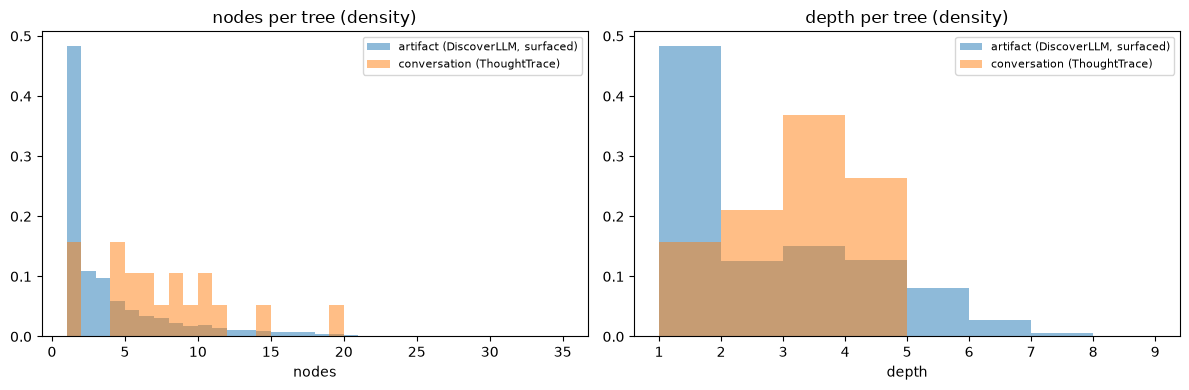

In [5]:
# --- Compare ---
both = pd.concat([art, conv], ignore_index=True)
summary = both.groupby("source")[["n_nodes", "depth", "branching"]].agg(["count", "mean", "median", "max"]).round(2)
print(summary)

if not conv.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    nmax, dmax = int(both["n_nodes"].max()), int(both["depth"].max())
    for src, sub in both.groupby("source"):
        axes[0].hist(sub["n_nodes"], bins=range(1, nmax + 2), alpha=0.5, density=True, label=src)
        axes[1].hist(sub["depth"], bins=range(1, dmax + 2), alpha=0.5, density=True, label=src)
    axes[0].set_title("nodes per tree (density)"); axes[0].set_xlabel("nodes"); axes[0].legend(fontsize=8)
    axes[1].set_title("depth per tree (density)"); axes[1].set_xlabel("depth"); axes[1].legend(fontsize=8)
    plt.tight_layout(); plt.show()

## Takeaways

- Both sides are now scoped to the **surfaced (green+yellow)** intent — DiscoverLLM artifacts restricted
  to `aware`/`satisfied` nodes, ThoughtTrace as extracted — so the structural distributions are
  size-comparable rather than full-vs-extracted.
- This is the original "real-conversation vs artifact" framing; the per-artifact DiscoverLLM-extraction
  comparison (recovery + architecture) lives in NB5 / NB6.
- Small N on the conversation side; scale with `scripts/extract_intent_trees.py`.